In [3]:
#%pip install --upgrade scikit-learn imbalanced-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE

# Configuration
pd.set_option('display.max_columns', None)
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
tcga_df = pd.read_csv('TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('weseq_processed_with_id_and_race_V2.csv')

In [6]:
tcga_df

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,1,1,77.89,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
835,1,0,85.18,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
836,1,1,77.49,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
837,1,0,63.33,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0


In [7]:
cgga_df

,CGGA_ID,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,CGGA_528,0,1,51,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,CGGA_579,0,1,42,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,CGGA_653,0,0,33,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,CGGA_715,0,0,43,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,CGGA_723,0,1,25,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,CGGA_P87,1,0,32,2,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,1
282,CGGA_P89,1,0,42,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
283,CGGA_P90,1,1,52,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
284,CGGA_P95,0,1,44,2,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0


In [8]:
if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop('CGGA_ID', axis=1)
print('TCGA values\n',tcga_df.count())
print('CGGA values\n',cgga_df.count())

TCGA values
 Grade               839
Gender              839
Age_at_diagnosis    839
Race                839
IDH1                839
TP53                839
ATRX                839
PTEN                839
EGFR                839
CIC                 839
MUC16               839
PIK3CA              839
NF1                 839
PIK3R1              839
FUBP1               839
RB1                 839
NOTCH1              839
BCOR                839
CSMD3               839
SMARCA4             839
GRIN2A              839
IDH2                839
FAT4                839
PDGFRA              839
dtype: int64
CGGA values
 Grade               286
Gender              286
Age_at_diagnosis    286
Race                286
IDH1                286
TP53                286
ATRX                286
PTEN                286
EGFR                286
CIC                 286
MUC16               286
PIK3CA              286
NF1                 286
PIK3R1              286
FUBP1               286
RB1                 286
N

In [9]:
tcgaClassRace = tcga_df.groupby("Race")

In [10]:
print(f'''white {len(tcgaClassRace.get_group(0))}\nblack or african american {len(tcgaClassRace.get_group(1))}\nasian {len(tcgaClassRace.get_group(2))}\namerican indian or alaska native {len(tcgaClassRace.get_group(3))}''')

white 765
black or african american 59
asian 14
american indian or alaska native 1


In [11]:
print('Dropping race to make it less biased on External Dataset')
if 'Race' in cgga_df.columns:
    cgga_df = cgga_df.drop('Race', axis=1)
if 'Race' in tcga_df.columns:
    tcga_df = tcga_df.drop('Race', axis=1)


Dropping race to make it less biased on External Dataset


In [12]:
tcga_df.head(10)

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,1,33.21,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,1,35.19,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,1,44.65,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,1,33.96,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,87.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [13]:
tcga_df.tail(10)

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
829,1,0,58.05,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
830,1,0,61.31,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
831,1,0,66.30,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
832,1,0,64.12,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
833,1,0,56.31,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
834,1,1,77.89,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
835,1,0,85.18,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
836,1,1,77.49,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
837,1,0,63.33,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0
838,1,0,76.61,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [14]:
cgga_df.head(10)

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,1,51,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,42,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,33,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,43,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,1,25,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,1,38,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,45,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
7,0,1,40,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,43,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0
9,0,0,31,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [15]:
cgga_df.tail(10)

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
276,1,1,46,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
277,0,1,40,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
278,0,1,28,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
279,0,1,40,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
280,0,1,34,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
281,1,0,32,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,1
282,1,0,42,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
283,1,1,52,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
284,0,1,44,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
285,1,0,52,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [16]:
tcgaClassGrade = tcga_df.groupby("Grade")
print('Glioma grade class information (0 = "LGG"; 1 = "GBM")')
gradeCount = tcga_df['Grade'].value_counts()
print(gradeCount)
print(f"Difference {len(tcgaClassGrade.get_group(0))-len(tcgaClassGrade.get_group(1))}")
print(tcga_df.nunique())

Glioma grade class information (0 = "LGG"; 1 = "GBM")
Grade
0    487
1    352
Name: count, dtype: int64
Difference 135
Grade                 2
Gender                2
Age_at_diagnosis    766
IDH1                  2
TP53                  2
ATRX                  2
PTEN                  2
EGFR                  2
CIC                   2
MUC16                 2
PIK3CA                2
NF1                   2
PIK3R1                2
FUBP1                 2
RB1                   2
NOTCH1                2
BCOR                  2
CSMD3                 2
SMARCA4               2
GRIN2A                2
IDH2                  2
FAT4                  2
PDGFRA                2
dtype: int64


In [17]:
print('LGG (WHO II/III) -> 0, GBM (WHO IV) -> 1 were converted when merged the clinical data and mutation.\nAlso Gender: Male -> 0, Female -> 1, Set to 2 (Asian) to match TCGA encoding for CGGA data(Dropped),\nNaN are classified as Wildtype -> 0, missense_variants,stop_gained as Mutant -> 1')

cggaClassGrade = cgga_df.groupby("Grade")
gradeCount = cgga_df['Grade'].value_counts()
print(gradeCount)
print(f"Difference {len(cggaClassGrade.get_group(0))-len(cggaClassGrade.get_group(1))}")
print(cgga_df.nunique())

LGG (WHO II/III) -> 0, GBM (WHO IV) -> 1 were converted when merged the clinical data and mutation.
Also Gender: Male -> 0, Female -> 1, Set to 2 (Asian) to match TCGA encoding for CGGA data(Dropped),
NaN are classified as Wildtype -> 0, missense_variants,stop_gained as Mutant -> 1
Grade
0    184
1    102
Name: count, dtype: int64
Difference 82
Grade                2
Gender               2
Age_at_diagnosis    56
IDH1                 2
TP53                 2
ATRX                 2
PTEN                 2
EGFR                 2
CIC                  2
MUC16                2
PIK3CA               2
NF1                  2
PIK3R1               2
FUBP1                2
RB1                  2
NOTCH1               2
BCOR                 2
CSMD3                2
SMARCA4              2
GRIN2A               2
IDH2                 2
FAT4                 2
PDGFRA               2
dtype: int64


In [18]:
maxage=tcga_df.Age_at_diagnosis.max()
minage=tcga_df.Age_at_diagnosis.min()
avgage = tcga_df.Age_at_diagnosis.mean()
print(f"TCGA min age {minage}, max age {maxage}, avg age {avgage}")

TCGA min age 14.42, max age 89.29, avg age 50.93541120381406


In [19]:
maxC_age=cgga_df.Age_at_diagnosis.max()
minC_age=cgga_df.Age_at_diagnosis.min()
avgC_age = cgga_df.Age_at_diagnosis.mean()
print(f"CGGA min age {minC_age}, max age {maxC_age}, avg age {avgC_age}")

CGGA min age 10, max age 76, avg age 41.96853146853147


In [20]:
common_cols = list(set(tcga_df.columns) & set(cgga_df.columns))

tcga_df1 = tcga_df[common_cols]
cgga_df1 = cgga_df[common_cols]

print(f"Original TCGA Count: {len(tcga_df1)} (Min Age: {tcga_df1['Age_at_diagnosis'].min()})")
print(f"Original CGGA Count: {len(cgga_df1)} (Min Age: {cgga_df1['Age_at_diagnosis'].min()})")

Original TCGA Count: 839 (Min Age: 14.42)
Original CGGA Count: 286 (Min Age: 10)


NameError: name 'sns' is not defined

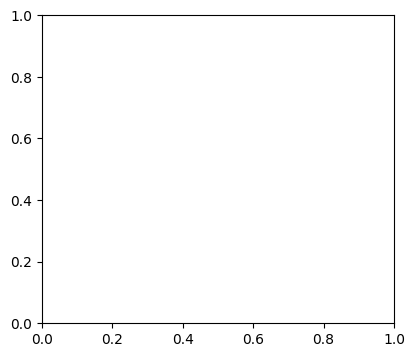

In [21]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(tcga_df['Age_at_diagnosis'], bins=20, color='blue', kde=True)
plt.title('TCGA Adult Age Dist')
plt.subplot(1, 2, 2)
sns.histplot(cgga_df['Age_at_diagnosis'], bins=20, color='red', kde=True)
plt.title('CGGA Adult Age Dist')
plt.show()

In [22]:
print("Z normalization")
mean_age = tcga_df['Age_at_diagnosis'].mean()
std_age = tcga_df['Age_at_diagnosis'].std()
z_scores = (tcga_df['Age_at_diagnosis'] - mean_age) / std_age
print(f'mean age: {mean_age} std age {std_age} Z score {z_scores}' )

Z normalization
mean age: 50.93541120381406 std age 15.70233865321824 Z score 0      0.023219
1     -0.777936
2     -1.004017
3     -1.156223
4     -1.237103
         ...   
834    1.716597
835    2.180859
836    1.691123
837    0.789347
838    1.635081
Name: Age_at_diagnosis, Length: 839, dtype: float64


In [23]:
outliers = tcga_df[np.abs(z_scores) > 3]

print(f"Adult Mean Age: {mean_age:.2f}")
if len(outliers) == 0:
    print("RESULT: No statistical outliers detected in Adult population.")
else:
    print(f"RESULT: {len(outliers)} statistical outliers detected (Age > 3 SDs from mean).")

Adult Mean Age: 50.94
RESULT: No statistical outliers detected in Adult population.


In [ ]:
scaler = MinMaxScaler()
scaler.fit(tcga_df[['Age_at_diagnosis']])
#transform TCGA
tcga_df['Age_at_diagnosis'] = scaler.transform(tcga_df[['Age_at_diagnosis']])

In [28]:
tcga_df.head(3)

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,0.492587,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0,0.324563,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0.277147,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
print(">>> SCENARIO 1 STARTING: 60-20-20 Split <<<")

In [ ]:
# Define Features (X) and Target (y)
X = tcga_adults.drop('Grade', axis=1)
y = tcga_adults['Grade']

# --- SPLIT 1: Separate Test Set (20%) ---
# We keep 80% for Model Development (Train + Val)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

# --- SPLIT 2: Separate Train (60%) and Validation (20%) ---
# The remaining 'temp' data is 80% of the total.
# We want Validation to be 20% of the TOTAL.
# So, relative to 'temp', validation is 20/80 = 0.25 (25%).
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.25, 
    stratify=y_temp, 
    random_state=42
)

print(f"Train Shape: {X_train.shape} (60%)")
print(f"Val Shape:   {X_val.shape} (20%)")
print(f"Test Shape:  {X_test.shape} (20%)")

In [ ]:
# Initialize Scaler
scaler = MinMaxScaler()

# We need to use .copy() to avoid Pandas warnings
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

# 1. Fit the scaler on TRAIN data
scaler.fit(X_train[['Age_at_diagnosis']])

# 2. Transform TRAIN
X_train['Age_at_diagnosis'] = scaler.transform(X_train[['Age_at_diagnosis']])

# 3. Transform VALIDATION (using Train's math)
X_val['Age_at_diagnosis'] = scaler.transform(X_val[['Age_at_diagnosis']])

# 4. Transform TEST (using Train's math)
X_test['Age_at_diagnosis'] = scaler.transform(X_test[['Age_at_diagnosis']])

print("Normalization Complete.")
print(f"Min Age (Train): {X_train['Age_at_diagnosis'].min()}")
print(f"Max Age (Train): {X_train['Age_at_diagnosis'].max()}")

In [ ]:
print(f"Original Class Distribution (Train): {Counter(y_train)}")

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Fit and Resample ONLY X_train and y_train
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Balanced Class Distribution (Train): {Counter(y_train_resampled)}")
print("SMOTE applied successfully.")

In [ ]:
# Prepare CGGA
X_cgga = cgga_adults.drop('Grade', axis=1)
y_cgga = cgga_adults['Grade']

# Apply the SAME scaler we trained on TCGA
X_cgga = X_cgga.copy()
X_cgga['Age_at_diagnosis'] = scaler.transform(X_cgga[['Age_at_diagnosis']])

print("CGGA External Validation Set Ready.")
print(X_cgga.head())

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# --- Model 1: Logistic Regression ---
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)


In [ ]:
# --- Model 2: Random Forest ---
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

In [ ]:
def evaluate_model(model, X, y, dataset_name="Validation"):
    print(f"\n--- {dataset_name} Results ({model.__class__.__name__}) ---")
    
    # Predict
    y_pred = model.predict(X)
    
    # Metrics
    acc = accuracy_score(y, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LGG', 'GBM'])
    disp.plot(cmap='Blues')
    plt.title(f"{dataset_name} Confusion Matrix")
    plt.show()

In [ ]:
evaluate_model(lr_model, X_val, y_val, "TCGA Internal Validation")

In [ ]:
evaluate_model(rf_model, X_val, y_val, "TCGA Internal Validation")

In [ ]:
evaluate_model(lr_model, X_cgga, y_cgga, "CGGA External Test")

In [ ]:
evaluate_model(rf_model, X_cgga, y_cgga, "CGGA External Test")

In [ ]:
val_acc_rf = accuracy_score(y_val, rf_model.predict(X_val))
ext_acc_rf = accuracy_score(y_cgga, rf_model.predict(X_cgga))

gap = val_acc_rf - ext_acc_rf

print(f"Random Forest Internal Accuracy: {val_acc_rf:.4f}")
print(f"Random Forest External Accuracy: {ext_acc_rf:.4f}")
print(f"Generalization Gap: {gap:.4f}")

In [ ]:
print(">>> SCENARIO 2 STARTING: 70-15-15 Split <<<")

In [ ]:
# --- 1. Split Logic ---
# A. Split Test Set (15% of Total)
X_temp_2, X_test_2, y_temp_2, y_test_2 = train_test_split(
    X, y, 
    test_size=0.15, 
    stratify=y, 
    random_state=42
)

# B. Split Train/Val from the remaining 85%
# Validation is 15% of TOTAL. Remaining 'temp' is 85%.
# Relative size = 15 / 85 = ~0.176
relative_val_size = 0.15 / 0.85

X_train_2, X_val_2, y_train_2, y_val_2 = train_test_split(
    X_temp_2, y_temp_2, 
    test_size=relative_val_size, 
    stratify=y_temp_2, 
    random_state=42
)

print(f"Train Shape: {X_train_2.shape} (70%)")
print(f"Val Shape:   {X_val_2.shape} (15%)")
print(f"Test Shape:  {X_test_2.shape} (15%)")

In [ ]:
# --- 2. Normalization (Fit on New Train) ---
scaler_2 = MinMaxScaler()
X_train_2 = X_train_2.copy()
X_val_2 = X_val_2.copy()
X_test_2 = X_test_2.copy()

# Fit on Train, Transform everything else
X_train_2['Age_at_diagnosis'] = scaler_2.fit_transform(X_train_2[['Age_at_diagnosis']])
X_val_2['Age_at_diagnosis'] = scaler_2.transform(X_val_2[['Age_at_diagnosis']])
X_test_2['Age_at_diagnosis'] = scaler_2.transform(X_test_2[['Age_at_diagnosis']])

In [ ]:
# --- 3. SMOTE (Train Only) ---
print(f"\nClass Distribution Before SMOTE: {Counter(y_train_2)}")
smote_2 = SMOTE(random_state=42)
X_train_res_2, y_train_res_2 = smote_2.fit_resample(X_train_2, y_train_2)
print(f"Class Distribution After SMOTE:  {Counter(y_train_res_2)}")

In [ ]:
rf_model_2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_2.fit(X_train_res_2, y_train_res_2)

In [ ]:
print("\n--- Internal Validation (Scenario 2) ---")
val_acc_2 = accuracy_score(y_val_2, rf_model_2.predict(X_val_2))
print(f"Validation Accuracy: {val_acc_2:.4f}")

In [ ]:
X_cgga_2 = cgga_adults.drop('Grade', axis=1).copy()
X_cgga_2['Age_at_diagnosis'] = scaler_2.transform(X_cgga_2[['Age_at_diagnosis']])
y_cgga_2 = cgga_adults['Grade']

print("\n--- External Validation (CGGA - Scenario 2) ---")
ext_acc_2 = accuracy_score(y_cgga_2, rf_model_2.predict(X_cgga_2))
print(f"External Accuracy: {ext_acc_2:.4f}")

In [ ]:
gap_2 = val_acc_2 - ext_acc_2
print(f"\nGeneralization Gap (Scenario 2): {gap_2:.4f}")